# Loading the Model

In [ ]:
%%capture
# ──────────────────────────────────────────────────────────────
# 0. Install (Colab only – safe elsewhere)
# ──────────────────────────────────────────────────────────────
import os, torch, json
if "COLAB_" in "".join(os.environ.keys()):
    !pip -q install --no-deps bitsandbytes accelerate xformers==0.0.29.post3 \
        peft trl==0.15.2 triton cut_cross_entropy unsloth_zoo \
        sentencepiece protobuf "datasets>=3.4.1" huggingface_hub hf_transfer \
        transformers==4.51.3 unsloth

# ──────────────────────────────────────────────────────────────
# 1. Load Qwen-3-14 B with EAGER attention (weights are returned)
# ──────────────────────────────────────────────────────────────
from unsloth import FastLanguageModel
from transformers import TextStreamer

model_name = "Qwen/Qwen3-14B"

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=model_name,
    max_seq_length=512,
    load_in_4bit=False,
    load_in_8bit=True,
    attn_implementation="eager",
)
# tell the config we’ll want attentions
model.config.output_attentions = True
model.eval().cuda()


In [2]:
# ──────────────────────────────────────────────────────────────
# 2. Build a dummy prompt and tensorise
# ──────────────────────────────────────────────────────────────
messages = [
    {"role": "user", "content": "In one word, name the tallest tower in the world."},
]
prompt = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=False,
)
inputs = tokenizer(prompt, return_tensors="pt", add_special_tokens=False).to("cuda")

# ──────────────────────────────────────────────────────────────
# 3. Forward pass with attention output
# ──────────────────────────────────────────────────────────────
with torch.inference_mode():
    out = model(
        **inputs,
        use_cache=False,
        output_attentions=True,
        return_dict=True,
    )

# out.attentions = tuple(n_layers) of tensors(bs, heads, seq, seq)
atts = out.attentions
print(f"Layers returned   : {len(atts)}")
print(f"Shape of layer 0  : {atts[0].shape}")


Layers returned   : 40
Shape of layer 0  : torch.Size([1, 40, 17, 17])


# Quick Setup Test

In [23]:
# === 1.  Define token categories (punctuation, digit, …) ===
import regex as re, torch
tok2cat = {}
rx_punct = re.compile(r'^\p{P}+$')
for tid, txt in enumerate(tokenizer.convert_ids_to_tokens(range(tokenizer.vocab_size))):
    if rx_punct.fullmatch(txt):
        tok2cat[tid] = "punct"
    elif txt.lstrip('▁').isdigit():
        tok2cat[tid] = "digit"


In [24]:
# === 2.  Attach attention hooks & zero accumulators ===
hooks = []
attn_acc = torch.zeros(model.config.num_hidden_layers,
                       model.config.num_attention_heads, device='cpu')
tok_acc  = torch.zeros_like(attn_acc)

def make_hook(layer_idx):
    def _hook(mod, inp, out):
        # grab attention tensor (bs, heads, tgt, src)
        attn_w = next((t.detach().cpu()[0]
                       for t in reversed(out)
                       if hasattr(t, "dim") and t.dim() == 4), None)
        if attn_w is None:
            return
        mask_1d = torch.tensor([tok2cat.get(t, '') == 'punct'
                                for t in cur_batch_ids], dtype=torch.bool)
        punct_mask = mask_1d.unsqueeze(0).unsqueeze(0).expand(
            attn_w.shape[0], attn_w.shape[1], -1)          # heads × tgt × src
        attn_acc[layer_idx] += (attn_w * punct_mask).sum((-1, -2))
        tok_acc[layer_idx]  += punct_mask.sum((-1, -2))
    return _hook

for i, blk in enumerate(model.model.layers):
    hooks.append(blk.self_attn.register_forward_hook(make_hook(i)))


In [25]:
# === 3.  Run inference loop to populate attn_acc / tok_acc ===
examples = [
    "In one word, name the tallest tower in the world.",
    "What is the capital of France?",
    "Solve 1+1 and give me the result.",
    "Explain why the sky is blue."
]
for text in examples:
    prompt = tokenizer.apply_chat_template([{"role":"user","content":text}],
                                           tokenize=False, add_generation_prompt=False)
    inputs = tokenizer(prompt, return_tensors="pt",
                       add_special_tokens=False).to("cuda")
    cur_batch_ids = inputs["input_ids"][0].tolist()
    with torch.inference_mode():
        _ = model(**inputs, use_cache=False, output_attentions=True)

print("Total punct tokens seen:", tok_acc.sum().item())


RuntimeError: The size of tensor a (17) must match the size of tensor b (40) at non-singleton dimension 1

In [15]:
# === 4.  Compute per-layer/head average attention on punctuation ===
punct_importance = attn_acc / tok_acc.clamp(min=1)
print("Non-zero heads:", (punct_importance > 0).sum().item())


tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])


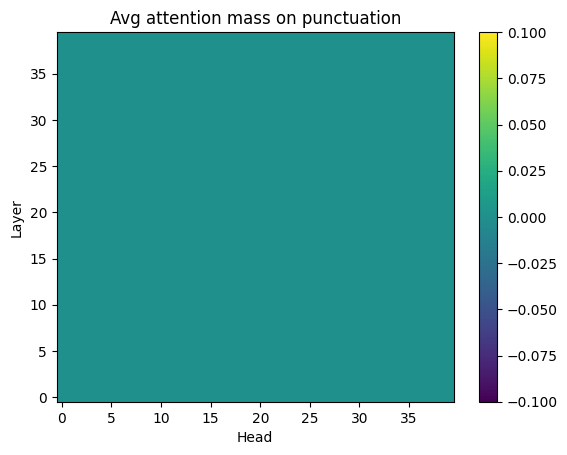

In [16]:
# === 5.  Plot heat-map ===
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(punct_importance, aspect='auto')
plt.colorbar(label="Avg attention mass on punctuation")
plt.xlabel("Head"); plt.ylabel("Layer"); plt.title("Punctuation attention heat-map")
plt.gca().invert_yaxis(); plt.show()
